In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2026-04-15 11:24:57.241773: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 11:24:57.243612: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-15 11:24:57.267584: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 11:24:57.267604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 11:24:57.268672: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Num GPUs Available:  0


2026-04-15 11:24:58.234860: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 11:24:58.238499: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:

import numpy as np
import matplotlib.pyplot as plt
import h5py

# from lfads_torch.metrics import r2_score
from paper.plot_helpers import class_accuracy

def eval_model(data,predictions,mask=None):
  if mask is None:
    mask = np.ones(data['valid_behavior'][:].shape[0],dtype=bool)

  directions = data['valid_target_direction']
  unique_dirs = sorted(set(directions))

  R2 = np.empty((len(unique_dirs))) # directions
  for i,d in enumerate(unique_dirs):
    precision_error = (predictions[mask & (directions==d)] - data['valid_behavior'][:][mask & (directions==d)])**2
    total_variance = (data['valid_behavior'][:][mask & (directions==d)] - data['valid_behavior'][:][mask & (directions==d)].mean(0))**2+1e-6
    R2[i] = 1 - precision_error.sum()/total_variance.sum() # sum over trials and time and space
  R_UIVE = R2.mean() #uninstructed variance explained

  precision_error = (predictions[mask] - data['valid_behavior'][:][mask])**2
  total_variance = (data['valid_behavior'][:][mask] - data['valid_behavior'][:][mask].mean(0))**2
  vec_R2 = 1 - precision_error.sum()/total_variance.sum() # sum over trials and time and space
  return vec_R2,R_UIVE

In [3]:
tT = 200 # ms target oscillatory frequency
dt = 100 # ms range
oscillatory_criterion = lambda a: (a > 2 * 10 * np.pi/(tT+dt)) & (a < 2 * 10 * np.pi/(tT-dt))


def plot_eigenspectrum(A, ax=None):

    if ax is None:
        _, ax = plt.subplots(1,1)

    evals, _ = np.linalg.eig(A)

    ax.plot([-1,1],[0,0],'k')
    ax.plot([0,0],[-1,1],'k')
    eigen_colors = []
    cc = 0 # color counter
    for e in evals:
        if e.imag >= 0: # plot conjugate pairs in the same color
            ax.plot(e.real,e.imag,'o',color='C'+str(cc))
            eigen_colors.append('C'+str(cc))
            if e.imag > 0:
                ax.plot(e.real,-e.imag,'o',color='C'+str(cc))
                eigen_colors.append('C'+str(cc))
            cc += 1
    # draw a line at 18 degrees
    for t in [tT-dt, tT, tT+dt]:
        tan = np.tan(2 * 10 * np.pi/t)
        style = 'k--' if t == tT else 'r--'
        ax.plot([0,np.sqrt(1-tan**2)],[0,tan],style)
        ax.plot([0,np.sqrt(1-tan**2)],[0,-tan],style)
    # draw a unit circle
    x = np.linspace(-1,1,100)
    y = np.sqrt(1-x**2)
    ax.plot(x,y,'k')
    y = -np.sqrt(1-x**2)
    ax.plot(x,y,'k')

    ax.axis('equal')
    # remove frame and ticks
    ax.axis('off')
    return eigen_colors

def plot_model_summary(model):
    _, ax = plt.subplots(1,3,figsize=(8,3))
    eigen_colors = plot_eigenspectrum(model.A, ax=ax[0])
    _, evecs = np.linalg.eig(model.A)
    ax[1].imshow(model.A, vmin=0, vmax=1)
    m = ax[2].imshow(evecs.real, vmin=0, vmax=1)
    n = model.A.shape[0]
    plt.xticks(np.arange(n),['⚫' for _ in range(n)])
    plt.yticks(np.arange(n),['⚫' for _ in range(n)])

    ax[0].set_title('Eigenvalues')
    ax[1].set_title('A matrix')
    ax[2].set_title('Eigenvectors')

    ax = plt.gca()
    for t,ec in zip(ax.xaxis.get_ticklabels(),eigen_colors):
        t.set_color(ec)
    for t,ec in zip(ax.yaxis.get_ticklabels(),eigen_colors):
        t.set_color(ec) 
    # plt.colorbar(mappable=m)

In [4]:
data = h5py.File("../datasets/Chewie_CO_FF_2016-09-21_session_vel_M1_spikes_go.h5", "r")
print(data.keys())
print(data["valid_recon_data"].shape)

<KeysViewHDF5 ['train_behavior', 'train_encod_data', 'train_epoch', 'train_inds', 'train_pos', 'train_recon_data', 'train_target_direction', 'train_vel', 'valid_behavior', 'valid_encod_data', 'valid_epoch', 'valid_inds', 'valid_pos', 'valid_recon_data', 'valid_target_direction', 'valid_vel']>
(127, 103, 72)


In [5]:
from DPAD import DPADModel
from DPAD.tools.flexible import fitDPADWithFlexibleNonlinearity
from DPAD.tools.evaluation import evalPrediction
idSys = DPADModel()

In [9]:
n_factors = 100
n_beh_factors = 100
mask = np.ones_like(data['train_epoch'],dtype=bool) # train on all epochs
# mask = data['train_epoch'][:] == 0 # train on the BL epoch only

yTrain = data["train_recon_data"][mask].reshape((-1,data["train_recon_data"].shape[-1])) / 0.01
zTrain = data["train_behavior"][mask].reshape((-1,data["train_behavior"].shape[-1]))
nx = n_factors
n1 = n_beh_factors

yTest = data["valid_recon_data"][:].reshape((-1,data["valid_recon_data"][:].shape[-1])) / 0.01
zTest = data["valid_behavior"][:]

In [10]:
methodCode = "DPAD_GSUT_iCVF4_RTR2_uAKCzCy1HL64U_ErSV16" # Defines search space over nonlinearities by flexible DPAD 
saveDir = "../results/DPAD/" # Directory to save results of fitting DPAD with different nonlinearities
selectedMethodCode, iCVRes = fitDPADWithFlexibleNonlinearity(yTrain, Z=zTrain, nx=nx, n1=n1, settings={}, 
                                                             methodCode=methodCode, saveDir=saveDir) # Fits DPAD with desired nonlinearities and selects the best performing option within training data
# save selectedMethodCode
with open(f"{saveDir}/selectedMethodCode.txt", "w") as f:
    f.write(selectedMethodCode)
# result: 'DPAD_RTR2_uAKCz1HL64U_ErSV16'

Considering 16 possible combinations of location/type for nonlinearities (this might take a while)...
408/408 [==============================] - 0s 269us/step


In [11]:
methodCode = "DPAD_GSUTy_iCVF4_RTR2_uAKCzCy1HL64U_ErSV16" # Defines search space over nonlinearities by flexible DPAD 
saveDir = "../results/DPAD/" # Directory to save results of fitting DPAD with different nonlinearities
selectedMethodCode_y, iCVRes = fitDPADWithFlexibleNonlinearity(yTrain, Z=zTrain, nx=nx, n1=n1, settings={}, 
                                                             methodCode=methodCode, saveDir=saveDir) # Fits DPAD with desired nonlinearities and selects the best performing option within training data
# save selectedMethodCode
with open(f"{saveDir}/selectedMethodCode_y.txt", "w") as f:
    f.write(selectedMethodCode_y)
# result: 'DPAD_RTR2_uAKCz1HL64U_ErSV16'

Considering 16 possible combinations of location/type for nonlinearities (this might take a while)...


408/408 [==============================] - 0s 368us/step


In [9]:
# show second best option
# iCVRes['settings']['casesToRun'][iCVRes['bestIndsAll'][0][2]]

In [10]:
zTrain.shape

(46965, 2)

In [7]:
selectedMethodCode = 'DPAD_RTR2_CzCy1HL64U_ErSV16'

idSysF = DPADModel()
epochs = 2500  # Default for this is 2500.
args = DPADModel.prepare_args(selectedMethodCode)
idSysF.fit(yTrain.T, Z=zTrain.T, nx=100, n1=100, epochs=epochs, **args)

zTestPredF, yTestPredF, xTestPredF = idSysF.predict(yTest) # Run inference to generate predictions


409/409 [==============================] - 0s 298us/step


In [12]:
# Predict behavior and neural activity, from past neural activity, using the learned model
print("Computing predictions for the learned model with optimal nonlinearity for behavior decoding")
###########
zTestPredF, yTestPredF, xTestPredF = idSysF.predict(yTest)

# Compute CC of decoding and self-prediction
zCCNonLinF = evalPrediction(zTest.reshape(-1, zTest.shape[-1]), zTestPredF, "CC")
# yCCNonLinF = evalPrediction(yTest, yTestPredF[...,0],"CC")
##########

print(
    f"Behavior decoding CC:\n  Nonlinear DPAD (Flexible; best nonlinearity for behavior decoidng) => {np.mean(zCCNonLinF):.3g}"
)

Computing predictions for the learned model with optimal nonlinearity for behavior decoding
367/367 [==============================] - 0s 353us/step
Behavior decoding CC:
  Nonlinear DPAD (Flexible; best nonlinearity for behavior decoidng) => 0.901


In [13]:
zTestPredF = zTestPredF.reshape(zTest.shape)
print("Test R2: ", eval_model(data,zTestPredF)[0])
print("Test UIVE: ", eval_model(data,zTestPredF)[1])

Test R2:  0.8121758670269175
Test UIVE:  -0.26644158877564406


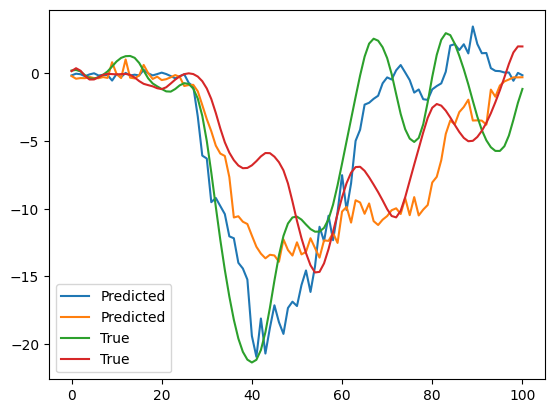

In [14]:
trial_i = 0
plt.plot(zTestPredF[trial_i], label='Predicted')
plt.plot(zTest[trial_i], label='True')
plt.legend()
plt.show()

In [15]:
zTestPredF

array([[[-0.15100838, -0.19756676],
        [-0.02486737, -0.39716014],
        [-0.06514262, -0.3484787 ],
        ...,
        [-0.54848766, -0.29710218],
        [ 0.0324105 , -0.29655   ],
        [-0.14076902, -0.28768906]],

       [[ 0.03835303, -0.40470996],
        [-0.26922634, -0.38233176],
        [-0.84800416, -0.10745833],
        ...,
        [ 0.03873292, -0.46302474],
        [ 0.7269206 , -0.75326353],
        [ 1.1174507 ,  0.29200098]],

       [[ 0.8048397 ,  0.9336427 ],
        [-0.5097765 ,  2.7266097 ],
        [-0.2707543 ,  2.2050092 ],
        ...,
        [ 0.04081981, -0.25600144],
        [-0.28260168, -0.5609091 ],
        [ 0.02273205, -0.3683127 ]],

       ...,

       [[ 0.10035218, -0.42909434],
        [ 0.09273681, -0.65030503],
        [ 0.00383828, -0.3586701 ],
        ...,
        [ 0.09406999, -0.72621053],
        [ 0.8132901 , -1.5486482 ],
        [ 0.58244616, -1.2604232 ]],

       [[ 0.732498  , -1.4030675 ],
        [-0.04642147, -0.71

In [16]:
# Linear DPAD
methodCode = 'DPAD_RTR2_ErSV16' 
# Notice that we still have `RTR2` (2 reties with different initialization) and `ErSV16` (early stopping based on validation data) in the method code.
# These two are generally good optimization settings to have, regardless of nonlinearity or linearity of the model.

idSysLin = DPADModel()
epochs = 2500  # Default for this is 2500.

# Prepare settings to make desired parameters in the learned model nonlinear
args = DPADModel.prepare_args(methodCode)
idSysLin.fit(yTrain.T, Z=zTrain.T, nx=nx, n1=n1, epochs=epochs, **args)

294/294 [==============================] - 0s 288us/step


In [17]:
args


{'init_method': None,
 'init_attempts': 2,
 'batch_size': None,
 'early_stopping_patience': 16,
 'early_stopping_measure': 'val_loss',
 'start_from_epoch_rnn': 0,
 'model1_Cy_Full': False,
 'model2_Cz_Full': False,
 'linear_cell': False,
 'LSTM_cell': False,
 'bidirectional': False,
 'allow_nonzero_Cz2': True,
 'has_Dyz': False,
 'skip_Cy': False,
 'steps_ahead': None,
 'steps_ahead_loss_weights': None,
 'zscore_inputs': True,
 'optimizer_name': 'Adam',
 'optimizer_args': None,
 'lr_scheduler_name': None,
 'lr_scheduler_args': None,
 'A_args': {'units': [],
  'use_bias': False,
  'activation': 'linear',
  'output_activation': 'linear'},
 'K_args': {'units': [],
  'use_bias': False,
  'activation': 'linear',
  'output_activation': 'linear',
  'unifiedAK': False},
 'Cy_args': {'units': [],
  'use_bias': True,
  'activation': 'linear',
  'output_activation': 'linear',
  'num_classes': 5},
 'Cz_args': {'units': [],
  'use_bias': False,
  'activation': 'linear',
  'output_activation': 'line

In [ ]:
args['Cy_args']['num_classes'] = 5